In [7]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import joblib 
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt 
import seaborn as sns

In [8]:
df = pd.read_csv("C:\\Users\\AKSHAYA\\OneDrive\\Desktop\\fullstack\\Project1\\HR_Employee_Attrition_data.csv")
print(df.shape)
print(df["Attrition"].value_counts(normalize=True))

(1470, 35)
Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64


step 2: perform EDA

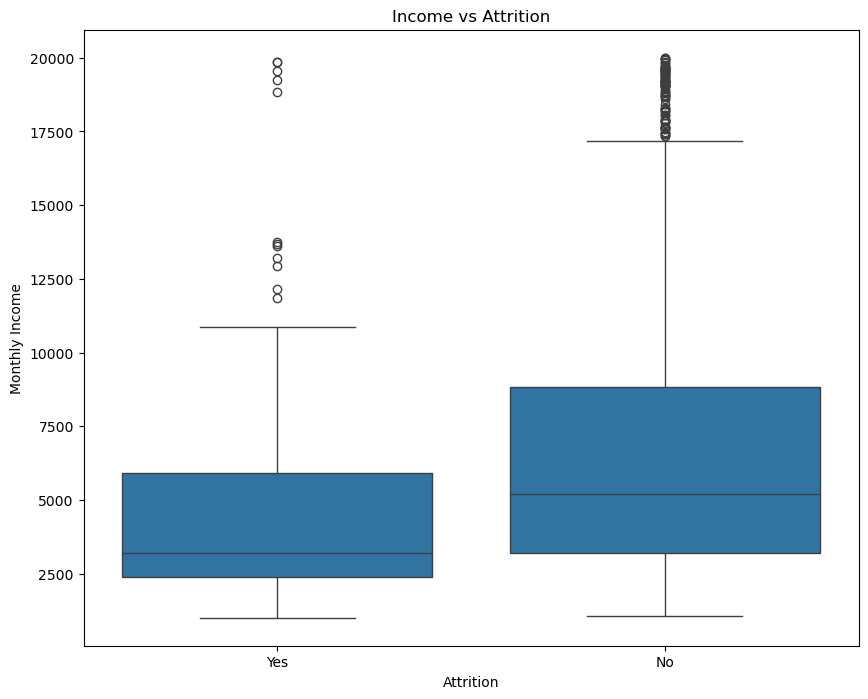

In [9]:
#Income vs Attrition
plt.figure(figsize=(10, 8))
sns.boxplot(x="Attrition", y = "MonthlyIncome", data=df)
plt.title("Income vs Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.show()

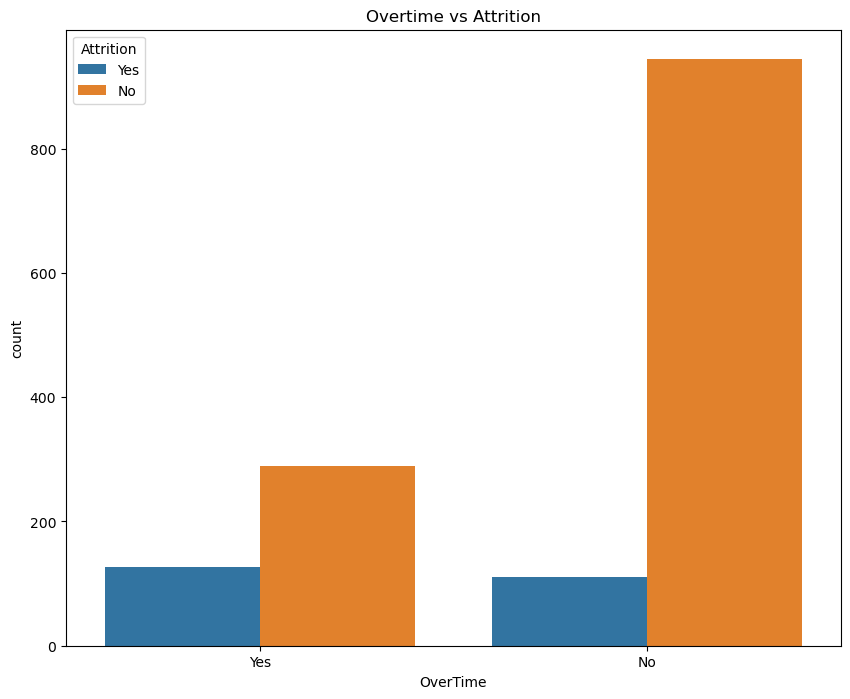

In [10]:
#OverTime vs Attrition
plt.figure(figsize=(10, 8))
sns.countplot(x="OverTime", hue="Attrition", data=df)
plt.title("Overtime vs Attrition")
plt.xlabel("OverTime")
plt.ylabel("count")
plt.legend(title="Attrition")
plt.show()

step 3:Data Preprocessing


In [11]:
#Drop irrelevant columns
df.drop(["EmployeeNumber", "EmployeeCount", "Over18", "StandardHours"], axis=1, inplace=True)
#df.info()

#Encode categorial variables
encoder = {}
for col in df.select_dtypes(include=["object"]).columns:
    lb = LabelEncoder()
    df[col] = lb.fit_transform(df[col])
    encoder[col] = lb

#split data into feature and target
x = df.drop("Attrition", axis=1)
y = df["Attrition"]

#split data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.4, random_state=42)

step 4: Modelling  and tunning


In [12]:
#Define the model
rf = RandomForestClassifier(random_state=42)

#Hyperparameter tuning
param_grid ={
    "n_estimators": [50, 100],
    "max_depth" : [10, 20, None],
    "min_samples_split" : [2, 5],
    "min_samples_leaf" :[1,2],
}

grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='f1')
grid_search.fit(x_train, y_train)

print("Best Hyperparameter:", grid_search.best_params_)


Best Hyperparameter: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


step 5: Evaluate the model

              precision    recall  f1-score   support

           0       0.88      0.99      0.93       507
           1       0.81      0.16      0.27        81

    accuracy                           0.88       588
   macro avg       0.85      0.58      0.60       588
weighted avg       0.87      0.88      0.84       588

[[504   3]
 [ 68  13]]


Text(0, 0.5, 'Feature')

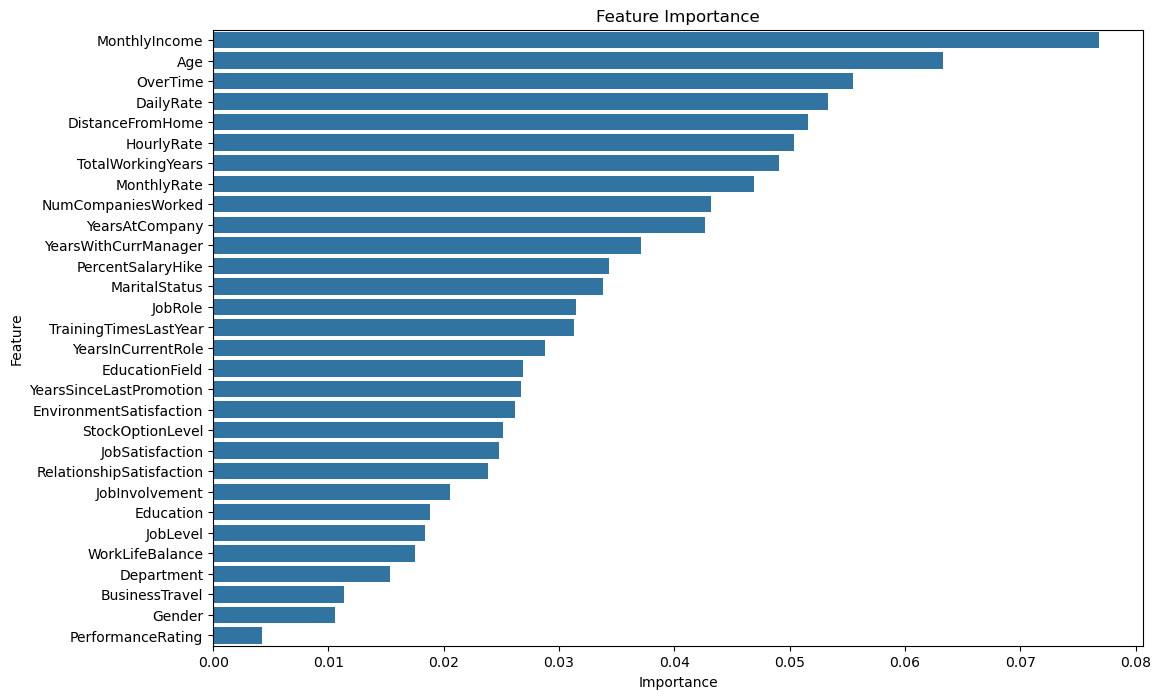

In [13]:
best_model = grid_search.best_estimator_
predictions = best_model.predict(x_test)

print(classification_report(y_test, predictions))
print(confusion_matrix(y_test, predictions))

importances = best_model.feature_importances_
feature_importance_df = pd.DataFrame({
    "Feature" : x.columns,
    "Importance" : importances

}).sort_values(by="Importance", ascending=False)
plt.figure(figsize=(12, 8))
sns.barplot(x="Importance", y="Feature", data=feature_importance_df)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

step 6 : saving the model


In [15]:
model = RandomForestClassifier(**grid_search.best_params_, random_state=42)
model.fit(x, y)

#save the model
joblib.dump(model, "employee_attrition_model.pkl")
joblib.dump(encoder, "label_encoder.pkl")
joblib.dump(x.columns.to_list(), "feature_columns.pkl")

['feature_columns.pkl']